# Brain Tumor Detection — Model Training

This notebook walks through the full training pipeline for the brain tumor classification model.

**Model:** ResNet50 (pretrained on ImageNet)  
**Task:** 4-class MRI classification — Glioma, Meningioma, No Tumor, Pituitary  
**Strategy:** Freeze all layers → fine-tune `layer4` + custom classifier head

## 1. Imports & Configuration

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models

# Configuration
DATA_DIR    = Path('../data')
MODELS_DIR  = Path('../models')
RESULTS_DIR = Path('../results')
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

CLASSES     = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 16
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device : {DEVICE}')
print(f'Classes: {CLASSES}')

Device : cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 2. Dataset & Data Loaders

We apply aggressive augmentation to the training set to help the model generalize.
The test set only gets resized and normalized — no augmentation.

In [3]:
class BrainTumorDataset(Dataset):
    def __init__(self, data_dir, split, transform=None):
        self.data_dir  = Path(data_dir) / split
        self.transform = transform
        self.samples   = []
        for label, cls in enumerate(CLASSES):
            class_path = self.data_dir / cls
            for img_name in os.listdir(class_path):
                self.samples.append((class_path / img_name, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = BrainTumorDataset(DATA_DIR, 'training', train_transform)
test_dataset  = BrainTumorDataset(DATA_DIR, 'testing',  test_transform)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Training samples : {len(train_dataset)}')
print(f'Testing samples  : {len(test_dataset)}')

Training samples : 5600
Testing samples  : 1600


### Preview augmented training images
This shows how augmentation transforms the same image differently each time.

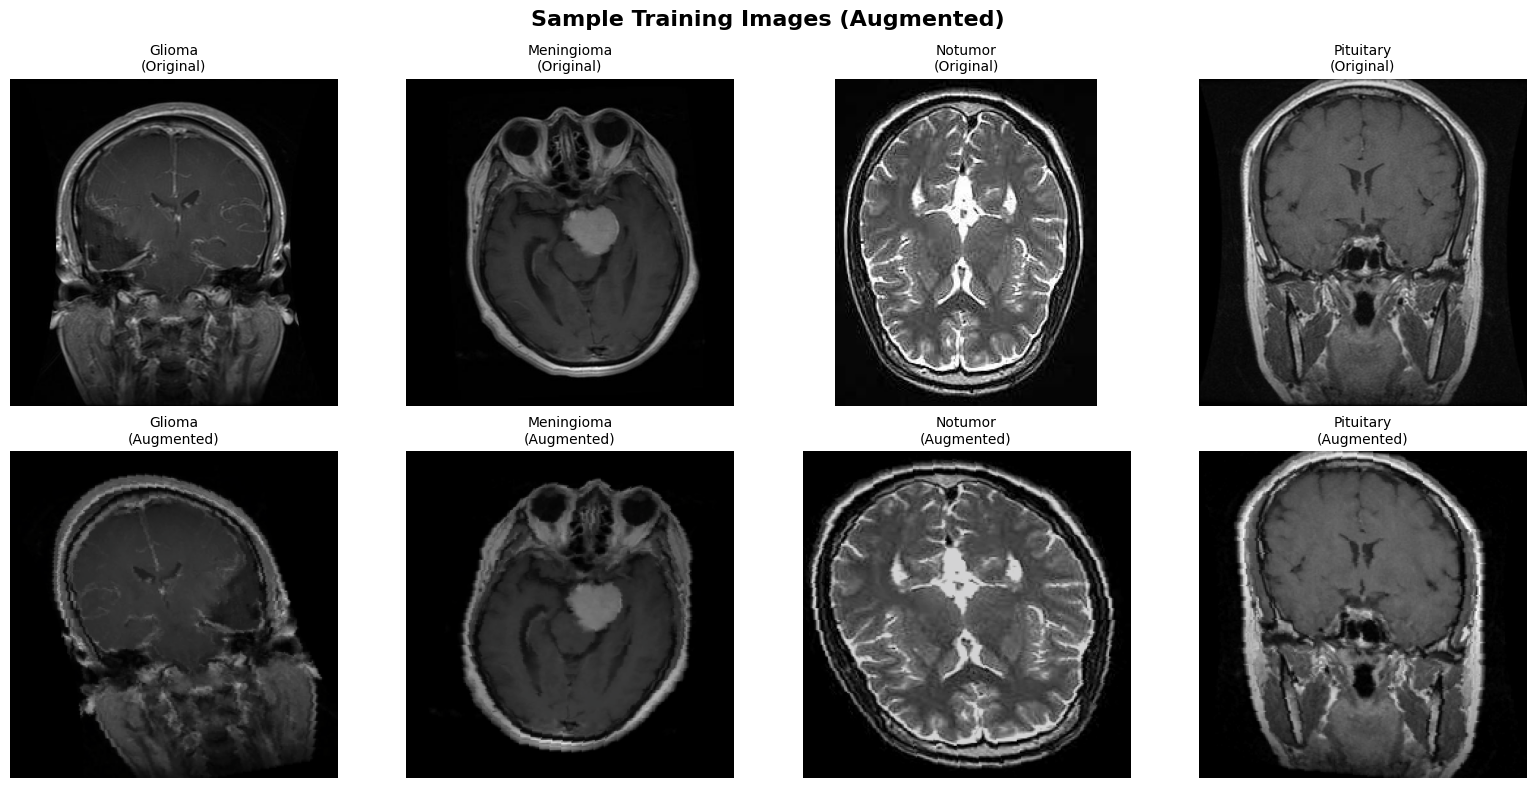

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Training Images (Augmented)', fontsize=16, fontweight='bold')

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

for i, cls in enumerate(CLASSES):
    # Get first image of this class
    cls_samples = [(p, l) for p, l in train_dataset.samples if l == i]
    img_path, _ = cls_samples[0]
    
    # Original
    orig = Image.open(img_path).convert('RGB')
    axes[0][i].imshow(orig)
    axes[0][i].set_title(f'{cls.capitalize()}\n(Original)', fontsize=10)
    axes[0][i].axis('off')
    
    # Augmented
    aug_tensor = train_transform(orig)
    aug_img    = aug_tensor.numpy().transpose(1, 2, 0)
    aug_img    = np.clip(aug_img * std + mean, 0, 1)
    axes[1][i].imshow(aug_img)
    axes[1][i].set_title(f'{cls.capitalize()}\n(Augmented)', fontsize=10)
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'augmentation_preview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Model Architecture

We use **ResNet50** pretrained on ImageNet.

**Why ResNet50?**
- Strong pretrained features from 1M+ ImageNet images transfer well to medical imaging
- Residual connections prevent vanishing gradients in deep networks
- Achieves 94% accuracy vs 84% with EfficientNetB0 on this dataset

**Fine-tuning strategy:**
- Freeze all layers to preserve pretrained features
- Unfreeze only `layer4` for domain-specific fine-tuning
- Train a custom classifier head from scratch

In [5]:
model = models.resnet50(weights='IMAGENET1K_V1')

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4 for fine-tuning
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace classifier head
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(256, NUM_CLASSES)
)

model = model.to(DEVICE)

# Count trainable parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')
print(f'Frozen parameters    : {total_params - trainable_params:,}')
print(f'\nClassifier head:\n{model.fc}')

Total parameters     : 24,033,604
Trainable parameters : 15,490,308
Frozen parameters    : 8,543,296

Classifier head:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=256, out_features=4, bias=True)
)


## 4. Training

**Key decisions:**
- **Class weights** — computed automatically to handle any class imbalance
- **Two learning rates** — `layer4` uses `1e-5` (careful fine-tuning), classifier uses `1e-4` (faster learning)
- **StepLR scheduler** — reduces LR by 10x at epoch 10 to stabilize convergence

In [6]:
# Class weights to handle imbalance
train_labels  = [label for _, label in train_dataset.samples]
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f'Class weights: {dict(zip(CLASSES, class_weights.cpu().numpy().round(3)))}')

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-5},
    {'params': model.fc.parameters(),     'lr': 1e-4}
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

Class weights: {'glioma': np.float32(1.0), 'meningioma': np.float32(1.0), 'notumor': np.float32(1.0), 'pituitary': np.float32(1.0)}


In [ ]:
history  = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
best_acc = 0.0

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss, train_correct = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    # Evaluate
    model.eval()
    test_loss, test_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs        = model(images)
            loss           = criterion(outputs, labels)
            test_loss    += loss.item() * images.size(0)
            test_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss = train_loss / len(train_loader.dataset)
    train_acc  = train_correct / len(train_loader.dataset)
    test_loss  = test_loss  / len(test_loader.dataset)
    test_acc   = test_correct / len(test_loader.dataset)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f'Epoch [{epoch+1:02d}/{EPOCHS}]  '
          f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  |  '
          f'Test Loss: {test_loss:.4f}  Acc: {test_acc:.4f}')

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), MODELS_DIR / 'best_model.pth')
        print(f'    Best model saved — Acc: {best_acc:.4f}')

    scheduler.step()

print(f'\n Best Test Accuracy: {best_acc:.4f}')

Epoch [01/16]  Train Loss: 0.7182  Acc: 0.7375  |  Test Loss: 0.5290  Acc: 0.8163
   💾 Best model saved — Acc: 0.8163
Epoch [02/16]  Train Loss: 0.3087  Acc: 0.8879  |  Test Loss: 0.4175  Acc: 0.8625
   💾 Best model saved — Acc: 0.8625
Epoch [03/16]  Train Loss: 0.2259  Acc: 0.9163  |  Test Loss: 0.3977  Acc: 0.8812
   💾 Best model saved — Acc: 0.8812
Epoch [04/16]  Train Loss: 0.1776  Acc: 0.9339  |  Test Loss: 0.3098  Acc: 0.9044
   💾 Best model saved — Acc: 0.9044
Epoch [05/16]  Train Loss: 0.1502  Acc: 0.9450  |  Test Loss: 0.3310  Acc: 0.9100
   💾 Best model saved — Acc: 0.9100
Epoch [06/16]  Train Loss: 0.1192  Acc: 0.9580  |  Test Loss: 0.3266  Acc: 0.9187
   💾 Best model saved — Acc: 0.9187
Epoch [07/16]  Train Loss: 0.1057  Acc: 0.9627  |  Test Loss: 0.3232  Acc: 0.9269
   💾 Best model saved — Acc: 0.9269
Epoch [08/16]  Train Loss: 0.0790  Acc: 0.9734  |  Test Loss: 0.3193  Acc: 0.9363
   💾 Best model saved — Acc: 0.9363
Epoch [09/16]  Train Loss: 0.0701  Acc: 0.9754  |  Test 

## 5. Training Curves

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

axes[0].plot(history['train_acc'], label='Train', color='steelblue', linewidth=2)
axes[0].plot(history['test_acc'],  label='Test',  color='coral',     linewidth=2)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_loss'], label='Train', color='steelblue', linewidth=2)
axes[1].plot(history['test_loss'],  label='Test',  color='coral',     linewidth=2)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.close()
print('✅ Training history saved → results/training_history.png')

✅ Training history saved → results/training_history.png
